In [1]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import seaborn as sns  # a useful plotting library on top of matplotlib
from tqdm.auto import tqdm # a nice progress bar

import sys
import os
sys.path.append('..')

# MLFlow Visualization
import mlflow
import mlflow.pytorch
from torchvision.utils import save_image
import torchvision.utils as utils

mlflow.set_experiment('simple_diffusion')

<Experiment: artifact_location='/home/jan/Uni/Applied_Deep-Learning/Simple_Diffusion/mlruns/1', creation_time=1781475154516, experiment_id='1', last_update_time=1781475154516, lifecycle_stage='active', name='simple_diffusion', tags={}, trace_location=None, workspace='default'>

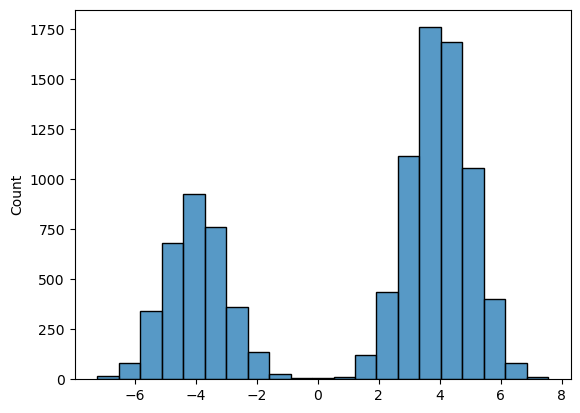

In [2]:
### This is a simple example of a diffusion model in 1D. ###

# generate a dataset of 1D data from a mixture of two Gaussians
# this is a simple example, but you can use any distribution
data_distribution = torch.distributions.mixture_same_family.MixtureSameFamily(
    torch.distributions.Categorical(torch.tensor([1, 2])),
    torch.distributions.Normal(torch.tensor([-4., 4.]), torch.tensor([1., 1.]))
)

dataset = data_distribution.sample(torch.Size([10000]))  # create training data set
dataset_validation = data_distribution.sample(torch.Size([1000])) # create validation data set

fig, ax = plt.subplots(1, 1)
sns.histplot(dataset)
plt.show()

In [3]:
# we will keep these parameters fixed throughout
# these parameters should give you an acceptable result
# but feel free to play with them
TIME_STEPS = 250
BETA = torch.tensor(0.02)
N_EPOCHS = 1000
BATCH_SIZE = 64
LEARNING_RATE = 0.8e-4

In [4]:
# define the neural network that predicts the amount of noise that was
# added to the data
# the network should have two inputs (the current data and the time step)
# and one output (the predicted noise)

device = (
    'cuda' if torch.cuda.is_available()
    else 'cpu'
)

g = nn.Sequential(
    nn.Linear(2, 128),
	nn.ReLU(),
	nn.Linear(128, 128),
	nn.ReLU(),
	nn.Linear(128, 1)
).to(device)

optimizer = optim.Adam(g.parameters(), lr=LEARNING_RATE)

In [5]:
def sample_reverse(g, count, track_steps=True):
    """
    Sample from the model by applying the reverse diffusion process

    Here, implement algorithm 2 of the DDPM paper (https://arxiv.org/abs/2006.11239)

    Parameters
    ----------
    model : torch.nn.Module
        The neural network that predicts the noise added to the data
    count : int
        The number of samples to generate in parallel

    Returns
    -------
    x : torch.Tensor
        The final sample from the model
    """
    g.eval()

    x = torch.randn(count, 1)

    trajectories = []

    with torch.no_grad():
        for t in reversed(range(TIME_STEPS)):
            t_tensor = torch.full((count, 1), t / TIME_STEPS, device=device)

            eps_theta = g(torch.cat([x, t_tensor], dim=1))

            beta_t = BETA
            alpha_t = 1 - beta_t
            alpha_bar_t = alpha_bar[t]

            mean = (1 / torch.sqrt(alpha_t)) * (
                x - (beta_t / torch.sqrt(1 - alpha_bar_t)) * eps_theta
            )

            if t > 0:
                z = torch.randn_like(x)
                x = mean + torch.sqrt(beta_t) * z
            else:
                x = mean

            if track_steps and (t % 25 == 0):
                trajectories.append(x.detach().cpu().numpy().squeeze())
                
    return x, trajectories

  0%|          | 0/1000 [00:00<?, ?it/s]

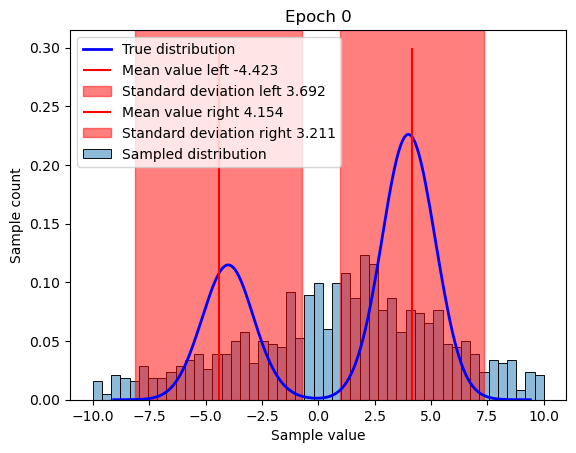

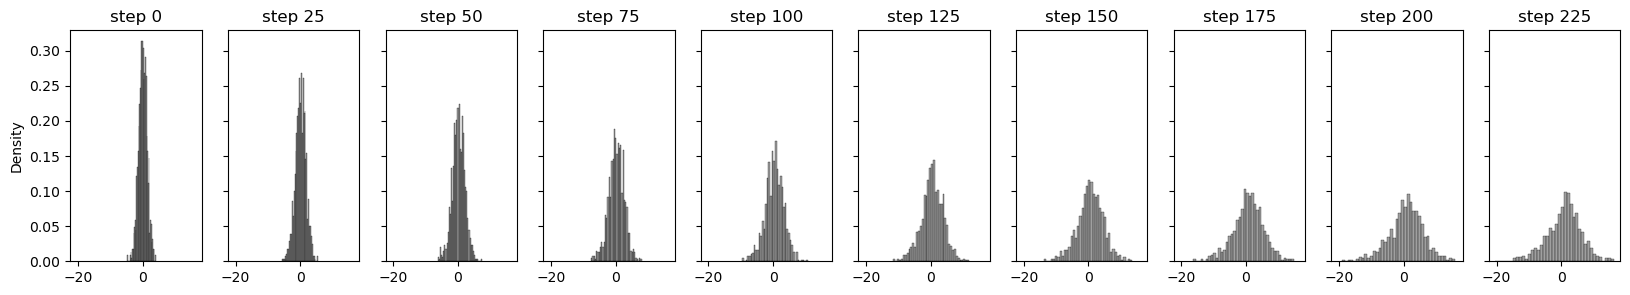

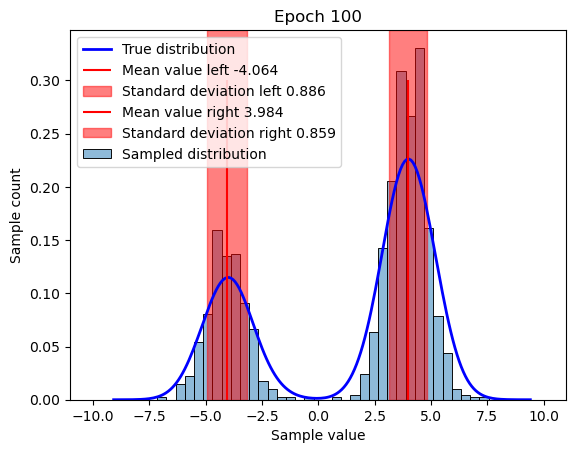

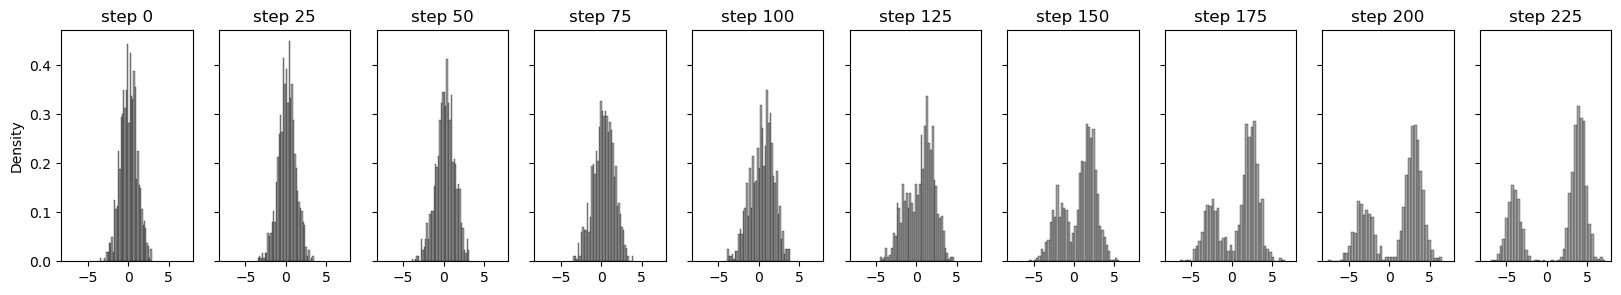

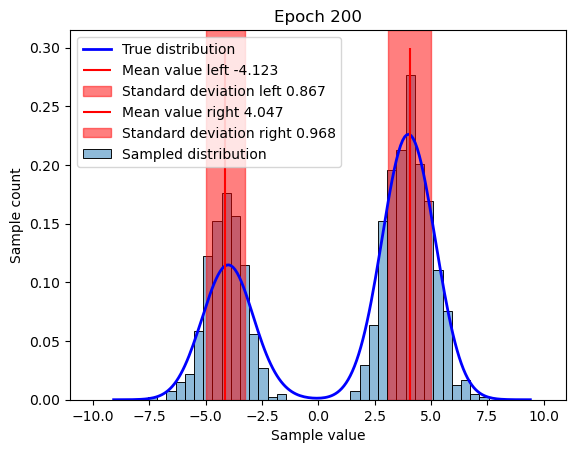

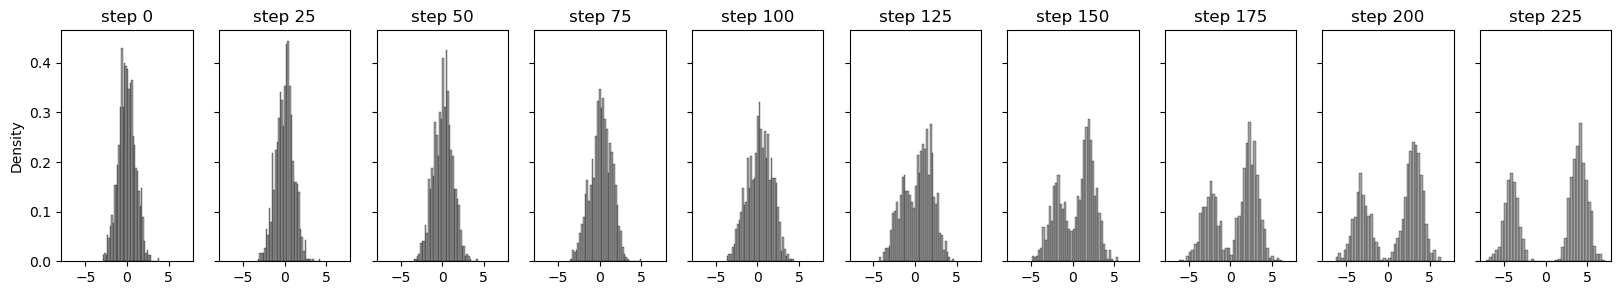

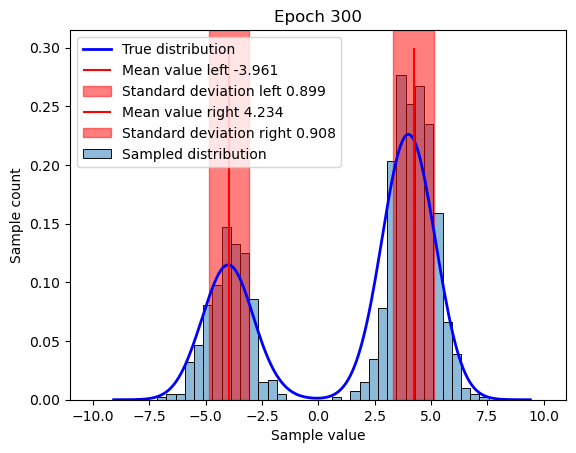

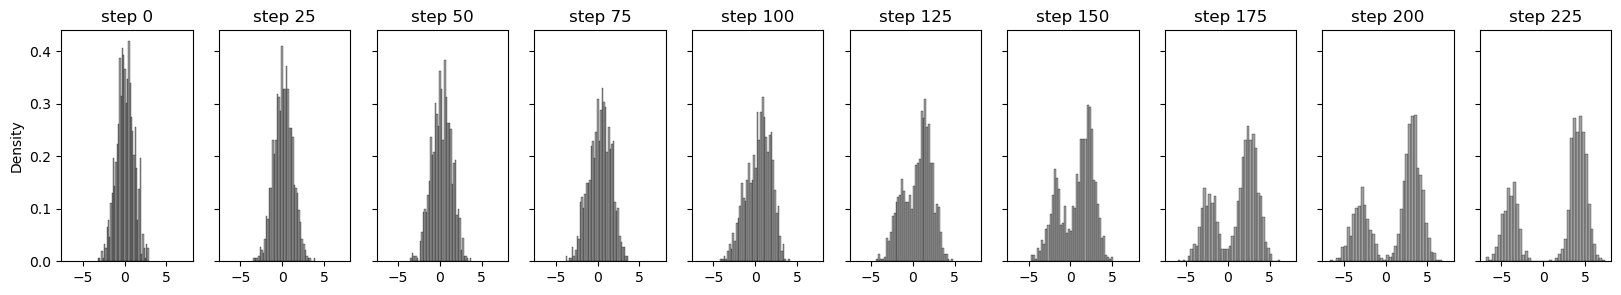

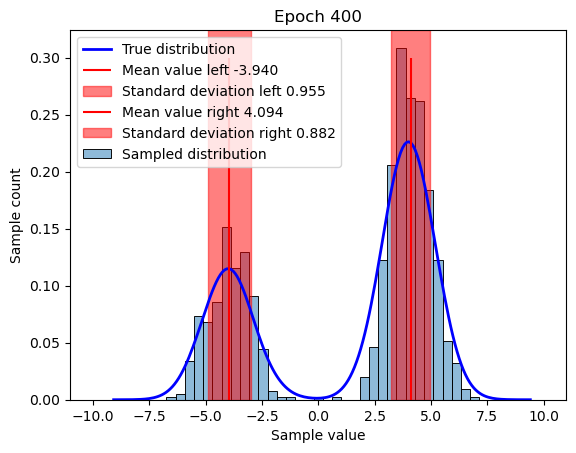

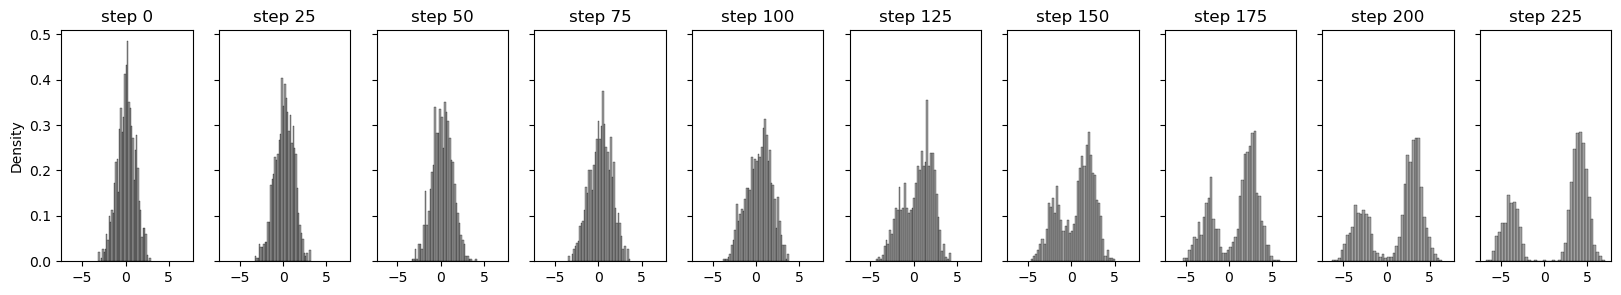

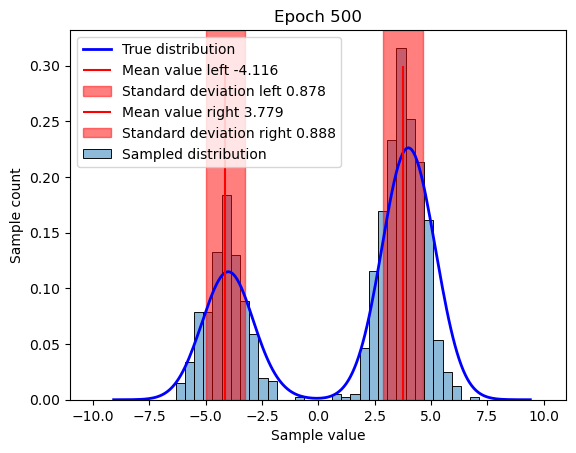

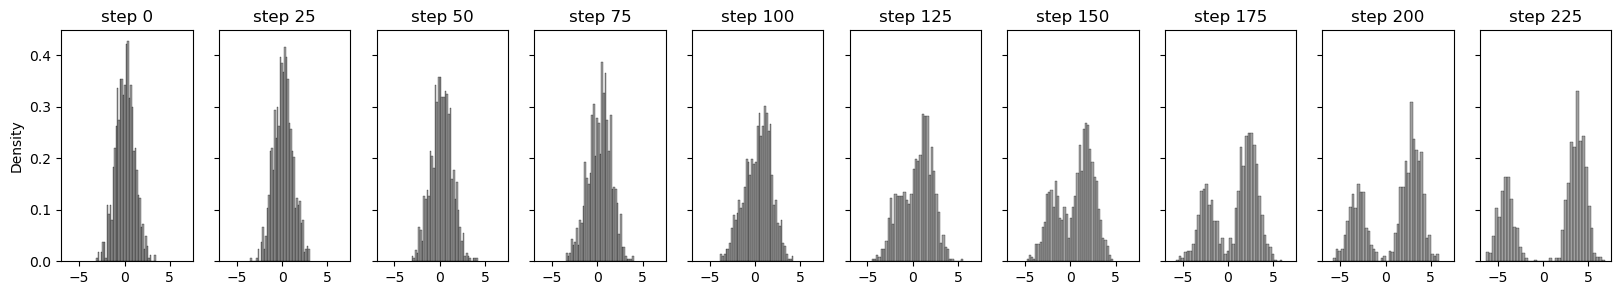

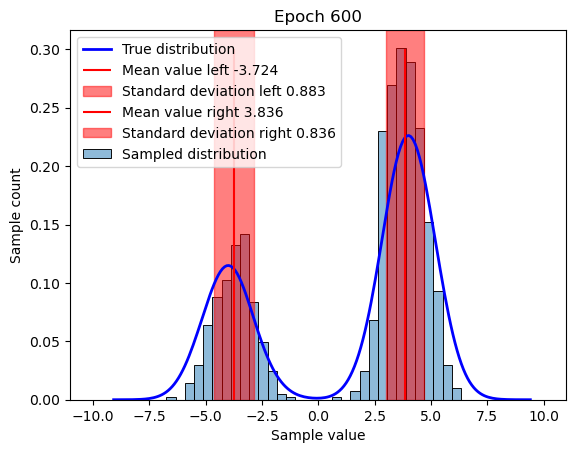

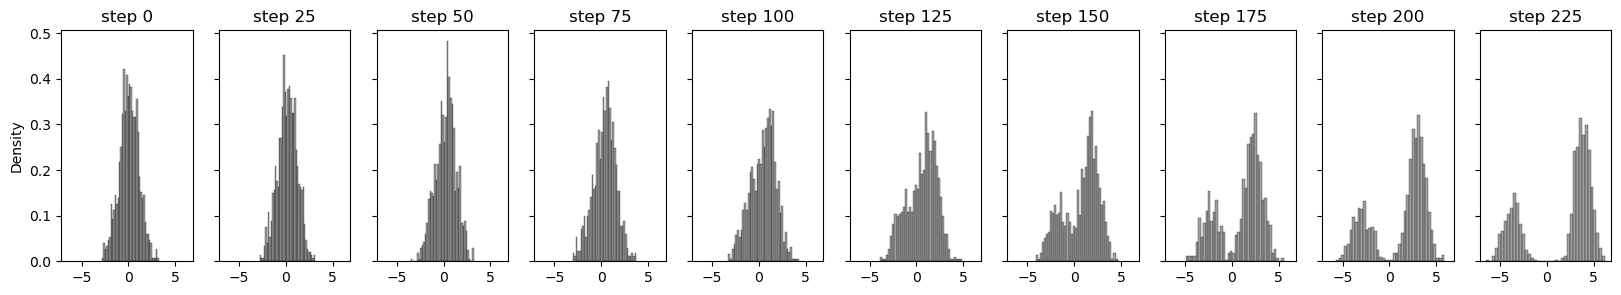

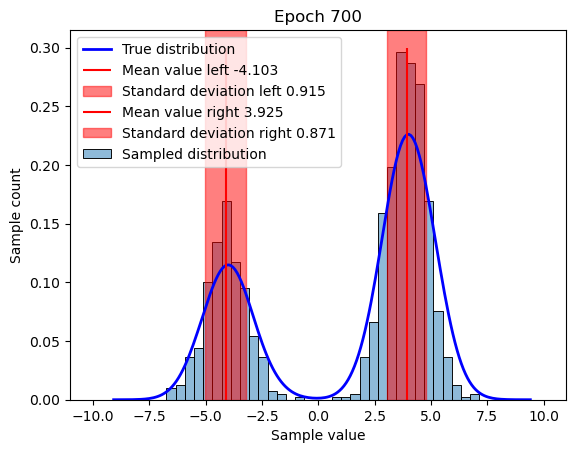

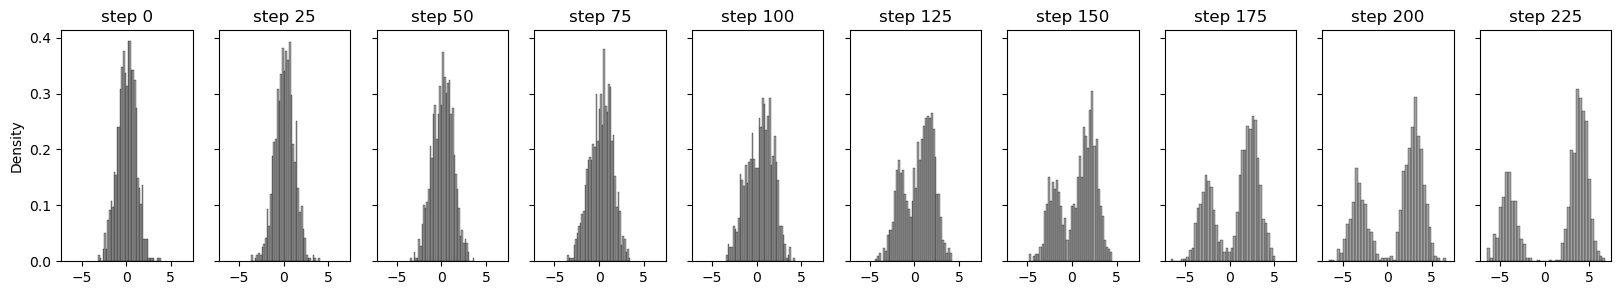

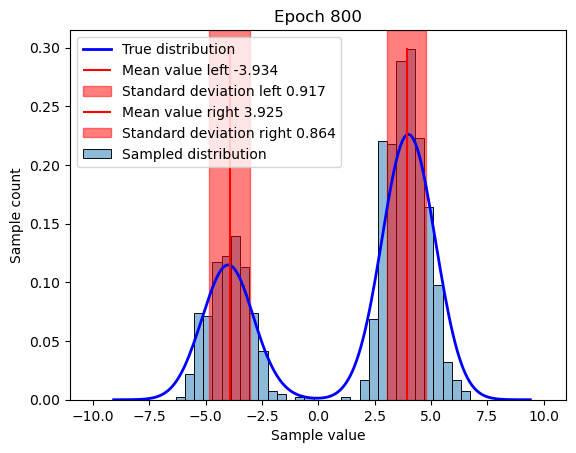

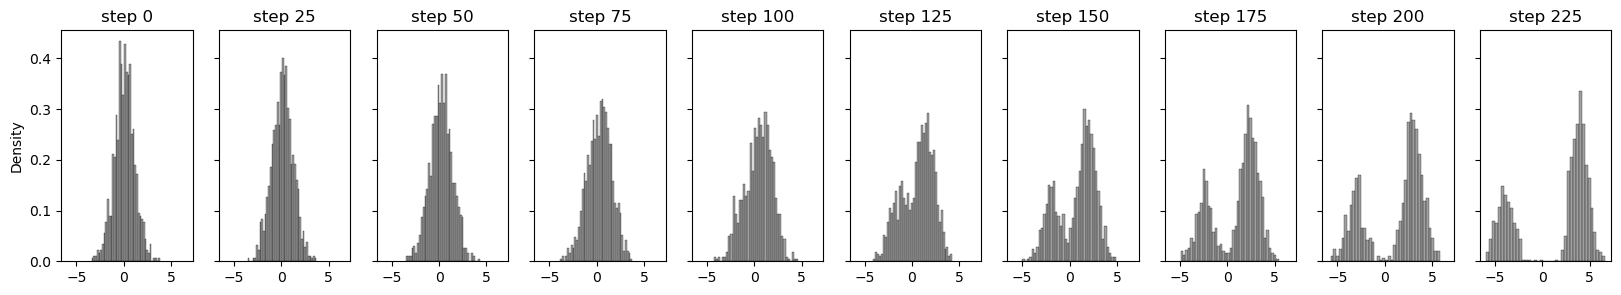

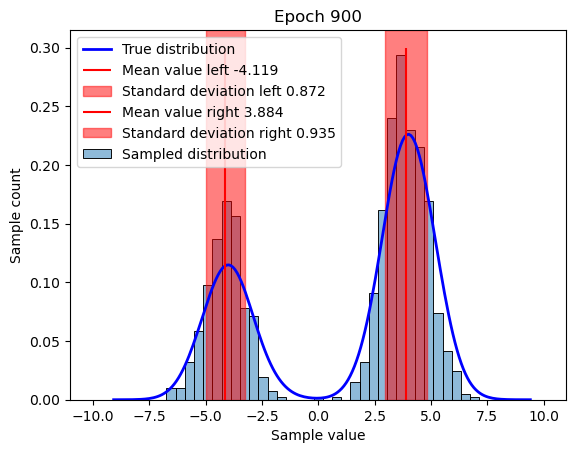

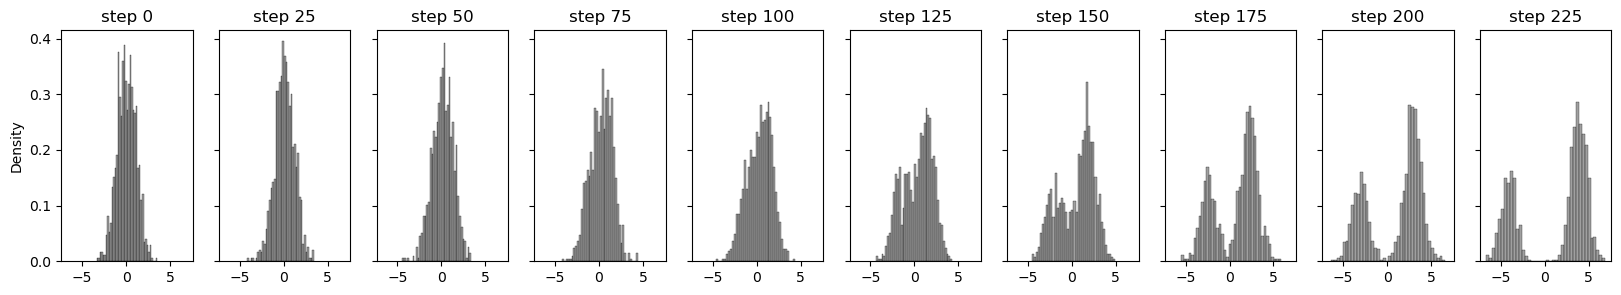

In [6]:
# Loss function
mse = torch.nn.MSELoss()

beta = torch.full((TIME_STEPS,), BETA)
alpha = 1.0 - beta
alpha_bar = torch.cumprod(alpha, dim=0)

epochs = tqdm(range(N_EPOCHS))  # this makes a nice progress bar

os.makedirs('images', exist_ok=True)
train_losses = []
val_losses = []

with mlflow.start_run():
    for e in epochs: # loop over epochs
        ####################
        ##### Training #####
        ####################
        g.train()
        total_train_loss = 0.0
        num_batches = 0
        # loop through batches of the dataset, reshuffling it each epoch
        indices = torch.randperm(dataset.shape[0])
        shuffled_dataset = dataset[indices]
        for i in range(0, shuffled_dataset.shape[0] - BATCH_SIZE, BATCH_SIZE):
            # sample a batch of data
            x0 = shuffled_dataset[i:i + BATCH_SIZE].to(device).unsqueeze(1)
            t = torch.randint(0, TIME_STEPS, (BATCH_SIZE,), device=device).unsqueeze(1)

            eps = torch.randn_like(x0)
            a_bar = alpha_bar[t]

            xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * eps
            t_in = t.float() / TIME_STEPS

            eps_pred = g(torch.cat([xt, t_in], dim=1))

            loss = mse(eps_pred, eps)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            num_batches += 1

        avg_train_loss = total_train_loss / num_batches
        train_losses.append(avg_train_loss)

        ######################
        ##### Validation #####
        ######################
        g.eval()
        with torch.no_grad():
            x0 = dataset_validation.to(device).unsqueeze(1)
            t = torch.randint(0, TIME_STEPS, (x0.shape[0],), device=device).unsqueeze(1)

            eps = torch.randn_like(x0)
            a_bar = alpha_bar[t]

            xt = torch.sqrt(a_bar) * x0 + torch.sqrt(1 - a_bar) * eps
            t_in = t.float() / TIME_STEPS

            eps_pred = g(torch.cat([xt, t_in], dim=1))

            val_loss = mse(eps_pred, eps)
            val_losses.append(val_loss.item())
 
        mlflow.log_metric('train_loss', avg_train_loss, step=e)
        mlflow.log_metric('val_loss', val_loss.item(), step=e)

        if e % 100 == 0:
            samples, traj = sample_reverse(g, 1000)
            samples = samples.detach().cpu().numpy()

            left_samples = samples[samples < 0]
            right_samples = samples[samples >= 0]

            left_sample_mean = left_samples.mean()
            left_sample_std = left_samples.std()
            right_sample_mean = right_samples.mean()
            right_sample_std = right_samples.std()
            
            # plot the samples
            fig, ax = plt.subplots(1, 1)
            bins = np.linspace(-10, 10, 50)
            sns.kdeplot(dataset, ax=ax, color='blue', label='True distribution', linewidth=2)
            sns.histplot(samples, ax=ax, bins=bins, color='red', label='Sampled distribution', stat='density')
            
            ax.vlines(left_sample_mean, 0, 0.30, color='red', label=f'Mean value left {left_sample_mean:.3f}')
            ax.axvspan(left_sample_mean - left_sample_std, left_sample_mean + left_sample_std, 0, 1, color='red', alpha=0.5, label=f'Standard deviation left {left_sample_std:.3f}')
            ax.vlines(right_sample_mean, 0, 0.30, color='red', label=f'Mean value right {right_sample_mean:.3f}')
            ax.axvspan(right_sample_mean - right_sample_std, right_sample_mean + right_sample_std, 0, 1, color='red', alpha=0.5, label=f'Standard deviation right {right_sample_std:.3f}')
            ax.legend()
            ax.set_xlabel('Sample value')
            ax.set_ylabel('Sample count')
            ax.set_title(f'Epoch {e}')

            plt.show()

            # diffusion steps
            fig, axes = plt.subplots(1, len(traj), figsize=(20, 3), sharex=True, sharey=True)

            for i, x in enumerate(traj):
                step = 25*i
                sns.histplot(x, bins=40, stat='density', ax=axes[i], color='gray')
                axes[i].set_title(f'step {step}')

            plt.show()

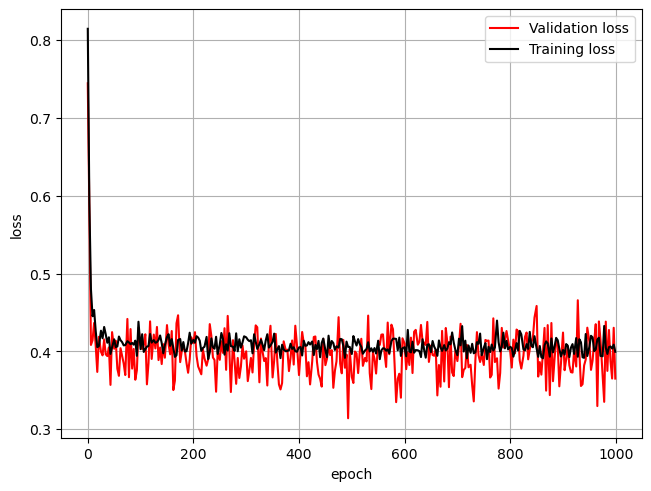

In [13]:
import pandas as pd

fig, ax = plt.subplots(1, 1, layout='constrained')

disc = pd.read_csv('train_loss.csv')
gen = pd.read_csv('val_loss.csv')

ax.plot(gen['step'], gen['value'], color='red', label='Validation loss')
ax.plot(disc['step'], disc['value'], color='black', label='Training loss')

ax.set(
    xlabel=('epoch'),
    ylabel=('loss'),
)

ax.legend()
ax.grid(True)

In [18]:
print('Best train_loss values: ', np.min(train_losses), ' in epoch: ', np.argmin(train_losses))
print('Best val_loss values: ', np.min(val_losses), ' in epoch: ', np.argmin(val_losses))

Best train_loss values:  0.38118759695536053  in epoch:  480
Best val_loss values:  0.31419575214385986  in epoch:  493
